Testing CNN model

In [24]:
import tensorflow as tf
import pandas as pd

from keras import Sequential, layers, callbacks, losses, utils, optimizers, applications
from keras.preprocessing import image_dataset_from_directory


Preprocess data and create the training and validation split 80% / 20%.

In [25]:
img_height = 150
img_width = 150

batch_size = 16

seed = 123

buffer = 1000

data_dir = "../data/tests/flower_photos"

input_shape = [img_height,img_width, 3]

ds_train = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    seed=seed,
    subset="training",
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=True
    )

ds_valid= image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    seed=seed,
    subset="validation",
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=True
    )
ds_valid.shuffle(buffer_size=buffer)
ds_train.shuffle(buffer_size=buffer)
class_names = ds_train.class_names # type: ignore
num_classes = 5
#print(class_names)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [26]:
%%capture
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in ds_train.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

2025-12-29 00:26:10.796508: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [27]:
%%capture
for image_batch, labels_batch in ds_train:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

In [28]:
AUTOTUNE = tf.data.AUTOTUNE

ds_train = ds_train.cache().prefetch(buffer_size=AUTOTUNE)
ds_valid = ds_valid.cache().prefetch(buffer_size=AUTOTUNE)



In [ ]:
padding = "same"

#body = applications.VGG16()
model_layers = [
    
    #Preprocessing
    layers.Rescaling(1./255),
    
    layers.RandomFlip(mode="vertical_and_horizontal"),
    layers.RandomContrast(0.5),
    layers.RandomZoom(0.2,0.2),
    layers.RandomSaturation(0.5),
    #layers.Solarization(),
    #layers.RandomGrayscale(),
    #layers.RandomGaussianBlur(),
    layers.RandomRotation(0.3),
    # Body
    

    layers.Conv2D(filters=32, kernel_size=3,activation='relu',padding=padding),
    layers.Conv2D(filters=32, kernel_size=3,activation='relu',padding=padding),
    layers.MaxPooling2D(),
    
    layers.Conv2D(filters=64, kernel_size=3,activation='relu',padding=padding),
    layers.Conv2D(filters=64, kernel_size=3,activation='relu',padding=padding),
    layers.MaxPooling2D(),
    
    layers.Conv2D(filters=128, kernel_size=3,activation='relu',padding=padding),
    layers.Conv2D(filters=128, kernel_size=3,activation='relu',padding=padding),
    layers.MaxPooling2D(),
    
    layers.Conv2D(filters=256, kernel_size=3,activation='relu',padding=padding),
    layers.Conv2D(filters=256, kernel_size=3,activation='relu',padding=padding),
    layers.MaxPooling2D(),
    
    layers.Conv2D(filters=512, kernel_size=3,activation='relu',padding=padding),
    layers.Conv2D(filters=512, kernel_size=3,activation='relu',padding=padding),
    layers.MaxPooling2D(),
    
    # Classifier head
    layers.Flatten(),
    layers.Dense(256,activation="relu"),
    layers.Dense(128,activation="relu"),
    layers.Dense(64,activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
]


In [ ]:

model = Sequential(layers=model_layers)

early_stopping = callbacks.EarlyStopping(patience=5,
                                      min_delta=0.001,restore_best_weights=True)

optimizer = optimizers.Adam(learning_rate=0.00001)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy'],
)
model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_saturation_1             │ ?                      │   0 (unbuilt) │
│ (RandomSaturation)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train the model

In [31]:
history = model.fit(
    ds_train,
    validation_data=ds_valid,
    callbacks=[early_stopping],
    epochs=100,
)

Epoch 1/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.2463 - loss: 1.6045 - val_accuracy: 0.2398 - val_loss: 1.6026
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.2674 - loss: 1.5936 - val_accuracy: 0.2834 - val_loss: 1.5934
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.2997 - loss: 1.5711 - val_accuracy: 0.2888 - val_loss: 1.5753
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step - accuracy: 0.3113 - loss: 1.5482 - val_accuracy: 0.2875 - val_loss: 1.5671
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step - accuracy: 0.3232 - loss: 1.5322 - val_accuracy: 0.2466 - val_loss: 1.5960
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.3277 - loss: 1.5174 - val_accuracy: 0.2738 - val_loss: 1.5732
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.3317 - loss: 1.5094 - val_accuracy: 0.2629 - val_loss: 1.5929
Epoch 8/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.3396 - loss: 1

<Axes: >

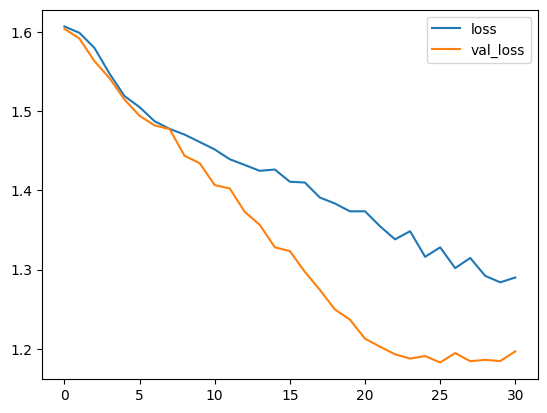

In [ ]:

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()